In [26]:
import pyscf

mol = pyscf.M(
    atom = 'F 0 0 0; H 0 0 1.1',  
    basis = 'sto-3g',
    symmetry = True,
    
)
myhf = mol.RHF().run()

#
# create an FCI solver based on the SCF object
#
cisolver = pyscf.fci.FCI(myhf)
print('E(FCI) = ' , cisolver.kernel()[0])

#
# create an FCI solver based on the SCF object
#
myuhf = mol.UHF().run()
cisolver = pyscf.fci.FCI(myuhf)
print('E(UHF-FCI) = ' , cisolver.kernel())

#
# create an FCI solver based on the given orbitals and the num. electrons and
# spin of the mol object
#
cisolver = pyscf.fci.FCI(mol, myhf.mo_coeff)
print('E(FCI) = ', cisolver.kernel())

converged SCF energy = -98.552190448278
E(FCI) =  -98.59512144913796
converged SCF energy = -98.5521904482781  <S^2> = 2.0428104e-14  2S+1 = 1
E(UHF-FCI) =  (-98.59512144913873, FCIvector([[ 9.82938580e-01,  3.24740235e-15,  2.10942375e-15,
             1.72706183e-02,  4.57998673e-03,  3.56440559e-05],
           [ 3.29218686e-18, -1.80331703e-02, -3.81639165e-17,
            -4.33415100e-18,  5.94560471e-17, -1.08158468e-18],
           [-1.41059269e-16,  2.06102936e-18, -1.80331703e-02,
            -1.98567287e-18,  3.50597299e-17, -7.67628852e-19],
           [ 1.72707404e-02, -6.82883445e-16, -4.37020956e-16,
            -1.74181901e-01,  2.90045223e-02,  4.14384890e-05],
           [ 4.57998388e-03,  1.15078349e-16,  7.17205163e-17,
             2.90045188e-02, -2.28123232e-02,  4.93283127e-04],
           [ 3.56440978e-05,  9.92312085e-19,  6.83024841e-19,
             4.14384944e-05,  4.93283132e-04, -3.12326402e-04]]))
E(FCI) =  (-98.59512144913795, FCIvector([[-9.82938595e-01

In [45]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
from jax import random
import matplotlib.pyplot as plt

class NN1(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=64)(x)  
        x = nn.relu(x)
        x = nn.Dense(features=1)(x)    
        return nn.tanh(x)              


def create_model(rng, input_shape):
    model = NN1()
    variables = model.init(rng, jnp.ones(input_shape))
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):
    preds = apply_fn({'params': params}, x)
    return jnp.mean((preds - y) ** 2)


@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss_fn(state.params)


def create_train_state(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


def generate_data(rng, num_samples, input_size):
    x = random.randint(rng, (num_samples, input_size), 0, 2)
    y = random.uniform(rng, (num_samples, 1), float,-1, 1)
    return x, y




Epoch 1, Loss: 0.3329399526119232
Epoch 2, Loss: 0.3164772689342499
Epoch 3, Loss: 0.3087753653526306
Epoch 4, Loss: 0.3031047582626343
Epoch 5, Loss: 0.2974250316619873
Epoch 6, Loss: 0.2925228178501129
Epoch 7, Loss: 0.28783008456230164
Epoch 8, Loss: 0.2834727168083191
Epoch 9, Loss: 0.27930140495300293
Epoch 10, Loss: 0.27494505047798157
Epoch 11, Loss: 0.2708098292350769
Epoch 12, Loss: 0.2665868103504181
Epoch 13, Loss: 0.2624557316303253
Epoch 14, Loss: 0.2583596110343933
Epoch 15, Loss: 0.254644513130188
Epoch 16, Loss: 0.2511852979660034
Epoch 17, Loss: 0.247594952583313
Epoch 18, Loss: 0.24373340606689453
Epoch 19, Loss: 0.24051988124847412
Epoch 20, Loss: 0.2369101494550705
Epoch 21, Loss: 0.23374268412590027
Epoch 22, Loss: 0.23091129958629608
Epoch 23, Loss: 0.227004736661911
Epoch 24, Loss: 0.2244541198015213
Epoch 25, Loss: 0.22205767035484314
Epoch 26, Loss: 0.2186780869960785
Epoch 27, Loss: 0.21605271100997925
Epoch 28, Loss: 0.21328595280647278
Epoch 29, Loss: 0.2106

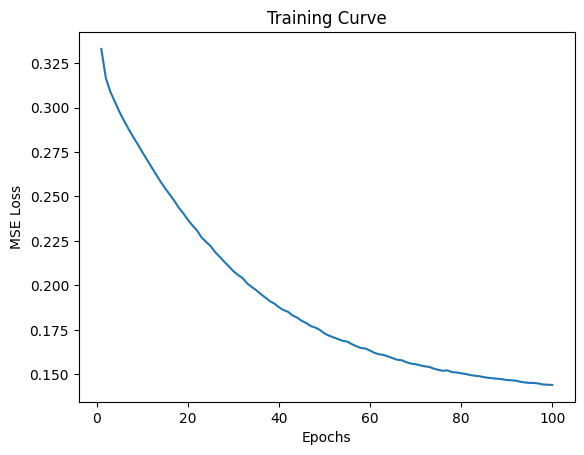

Training complete


In [49]:
# Main function
def main():
    rng = random.PRNGKey(0)
    input_size = 10  # Example input size
    num_samples = 1000  # Number of training samples
    
    x_train, y_train = generate_data(rng, num_samples, input_size)
    
    model, variables = create_model(rng, (input_size,))
    state = create_train_state(rng, model, variables)
    
    # Training loop
    num_epochs = 100
    batch_size = 32
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()